# Visualization Summary — LVGP vs MixedSingleTaskGP vs Separated GP

Loads the three completed BO sweeps (`study_v2`=LVGP, `study_v2_cat`=MixedSingleTaskGP,
`study_v2_gp`=Separated GP / per-category SingleTaskGP) and produces the six deliverables:

1. Model comparison (best true objective vs iteration) — 5 headline acquisitions
2. Acquisition comparison, LVGP only — 3 metrics vs iteration
3. Final performance summary table (mean ± s.e. over seeds, all model x acquisition cells)
4. Final objective–variance scatter (one point per seed)
5. Hyperparameter sensitivity (HAEI / ANPEI / RAHBO), LVGP only — boxplots
6. Replicate (n_rep) sensitivity

**Note on n_rep:** the sweep only has `n_rep in {3, 5, 10}` (30 seeds each) — there is no
`n_rep=20` run in `study_v2*/results`, so section 6 uses `{3, 5, 10}` instead of `{3, 5, 10, 20}`.

**Note on "best" hyperparameter:** for HAEI/ANPEI/RAHBO, "best" is selected as the value of
γ/β/α that minimizes the mean **final true objective** on **LVGP** at `n_rep=10`, then that
same configuration is reused for the other two models wherever a cross-model comparison needs
one representative setting per acquisition family (so the comparison is apples-to-apples).

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import os, sys; sys.path.insert(0, os.path.abspath("study_v2_cat"))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from utils import (StudyResults, compare_studies_multi, problem)
from utils.results import _cfg_param

lvgp = StudyResults.load("study_v2/results")
mix  = StudyResults.load("study_v2_cat/results")
sep  = StudyResults.load("study_v2_gp/results")

MODEL_LABELS = ["LVGP", "MixedSingleTaskGP", "Separated GP"]
studies = [(lvgp, "LVGP"), (mix, "MixedSingleTaskGP"), (sep, "Separated GP")]

F_STAR = problem.ground_truth_min()
print({lab: len(s.runs) for s, lab in studies}, "runs | f* =", round(F_STAR, 4))
print("n_rep available:", lvgp.n_reps, mix.n_reps, sep.n_reps)

{'LVGP': 1080, 'MixedSingleTaskGP': 1080, 'Separated GP': 1080} runs | f* = 0.4651
n_rep available: [3, 5, 10] [3, 5, 10] [3, 5, 10]


## Shared config & helpers

In [ ]:
ALPHA_EVAL = 1.0      # fixed evaluation weight for the reporting metric f(x) + ALPHA_EVAL*sigma^2(x)
N_REP_MAIN = 10       # standard replicate budget used for sections 1, 2, 3, 4
EXCEL_DIR = "results_all_studies"
os.makedirs(EXCEL_DIR, exist_ok=True)


def f_domain_max():
    """True noise-free global MAXIMUM over x1 and all categorical levels (for the success tolerance)."""
    x1 = np.linspace(problem.LB, problem.UB, 4000)
    return float(max(problem.f_true(x1, v).max() for v in problem.VAR_FCTR))


F_MIN = F_STAR
F_MAX = f_domain_max()
TOLERANCE = 0.05 * (F_MAX - F_MIN)
SUCCESS_THRESHOLD = F_MIN + TOLERANCE
print(f"f_min={F_MIN:.4f}  f_max={F_MAX:.4f}  tolerance={TOLERANCE:.4f}  success threshold={SUCCESS_THRESHOLD:.4f}")


def best_param(study, family, n_rep=N_REP_MAIN):
    """Hyperparameter value (gamma/beta/alpha) of `family` that minimizes the mean final
    TRUE objective on `study` at the given n_rep -- the 'best Xxx' setting used everywhere below."""
    cands = sorted({p for a, p in problem.CONFIG_ORDER if a == family})
    scores = {}
    for p in cands:
        cfg = problem.canon_cfg(family, p)
        vals = [study._true_obj_of_samples(r)[study._best_sample_idx(r, True)]
                for r in study.runs if StudyResults.cfg_key(r) == cfg and r["n_rep"] == n_rep]
        if vals:
            scores[p] = float(np.mean(vals))
    return min(scores, key=scores.get)


BEST = {fam: best_param(lvgp, fam, N_REP_MAIN) for fam in ("haei", "anpei", "rahbo")}
print("Best LVGP hyperparameters (n_rep=%d):" % N_REP_MAIN, BEST)

# the 5 headline acquisition cases used throughout (EI, LCB, best HAEI/ANPEI/RAHBO)
HEADLINE_CFGS = [
    problem.canon_cfg("ei", float("nan")),
    problem.canon_cfg("lcb", float("nan")),
    problem.canon_cfg("haei", BEST["haei"]),
    problem.canon_cfg("anpei", BEST["anpei"]),
    problem.canon_cfg("rahbo", BEST["rahbo"]),
]
HEADLINE_TAGS = [problem.acf_tag(c[0], _cfg_param(c)) for c in HEADLINE_CFGS]
HEADLINE_LABELS = [problem.label(c[0], _cfg_param(c)) for c in HEADLINE_CFGS]
print("Headline configs:", HEADLINE_LABELS)

f_min=0.4651  f_max=308.1291  tolerance=15.3832  success threshold=15.8483
Best LVGP hyperparameters (n_rep=10): {'haei': 0.5, 'anpei': 0.8, 'rahbo': 0.5}
Headline configs: ['EI', 'LCB', 'HAEI(γ=0.5)', 'ANPEI(β=0.8)', 'RAHBO(α=0.5)']


In [30]:
def build_long_df(studies_labels, alpha_eval=ALPHA_EVAL):
    """Per-run tidy table: one row per (model, acquisition config, n_rep, seed) with the
    FINAL true objective, the analytic TRUE noise variance at that final design (both ranked
    by the TRUE f among all sampled points -- i.e. the ground-truth best, matching every other
    'is_ground_truth=True' selection used elsewhere in this repo), and the derived robust
    objective f(x) + alpha_eval*sigma^2(x)."""
    rows = []
    for study, model_lab in studies_labels:
        for r in study.runs:
            idx = study._best_sample_idx(r, True)
            f_final = float(study._true_obj_of_samples(r)[idx])
            v_final = float(study._true_var_of_samples(r)[idx])
            cfg = StudyResults.cfg_key(r)
            rows.append(dict(
                model=model_lab, acf=r["acf"], param=r["param"], cfg=cfg,
                acq_label=problem.label(r["acf"], r["param"]),
                n_rep=r["n_rep"], seed=r["seed"],
                final_true_f=f_final, final_true_var=v_final,
                robust_obj=f_final + alpha_eval * v_final,
            ))
    df = pd.DataFrame(rows)
    df["success"] = df["final_true_f"] <= SUCCESS_THRESHOLD
    return df


def select_cfg(df, cfg):
    """Boolean mask selecting rows matching a canonical (acf, param) cfg key -- NOT plain
    `df.cfg == cfg`, since comparing a tuple-valued Series to a tuple literal is ambiguous in
    pandas (it can try to broadcast the tuple elementwise instead of comparing whole tuples)."""
    acf, p = cfg
    if p == "na":
        return (df["acf"] == acf) & df["param"].isna()
    return (df["acf"] == acf) & np.isclose(df["param"].astype(float), float(p))


LONG_DF = build_long_df(studies)
LONG_DF.head()

,model,acf,param,cfg,acq_label,n_rep,seed,final_true_f,final_true_var,robust_obj,success
0,LVGP,anpei,0.2,"(anpei, 0.2)",ANPEI(β=0.2),3,1,0.551512,1.359224,1.910736,True
1,LVGP,anpei,0.2,"(anpei, 0.2)",ANPEI(β=0.2),3,2,0.552945,1.358837,1.911782,True
2,LVGP,anpei,0.2,"(anpei, 0.2)",ANPEI(β=0.2),3,3,0.485500,1.433122,1.918622,True
3,LVGP,anpei,0.2,"(anpei, 0.2)",ANPEI(β=0.2),3,4,0.727485,1.325420,2.052905,True
4,LVGP,anpei,0.2,"(anpei, 0.2)",ANPEI(β=0.2),3,5,0.811892,1.313996,2.125888,True


## 1. Model comparison — LVGP vs MixedSingleTaskGP vs Separated GP

Best true objective value vs BO iteration, for the 5 headline acquisition cases
(EI, LCB, best HAEI, best ANPEI, best RAHBO), at `n_rep=10`. This is the figure
for claim (1): does LVGP converge faster and land on a better final solution?

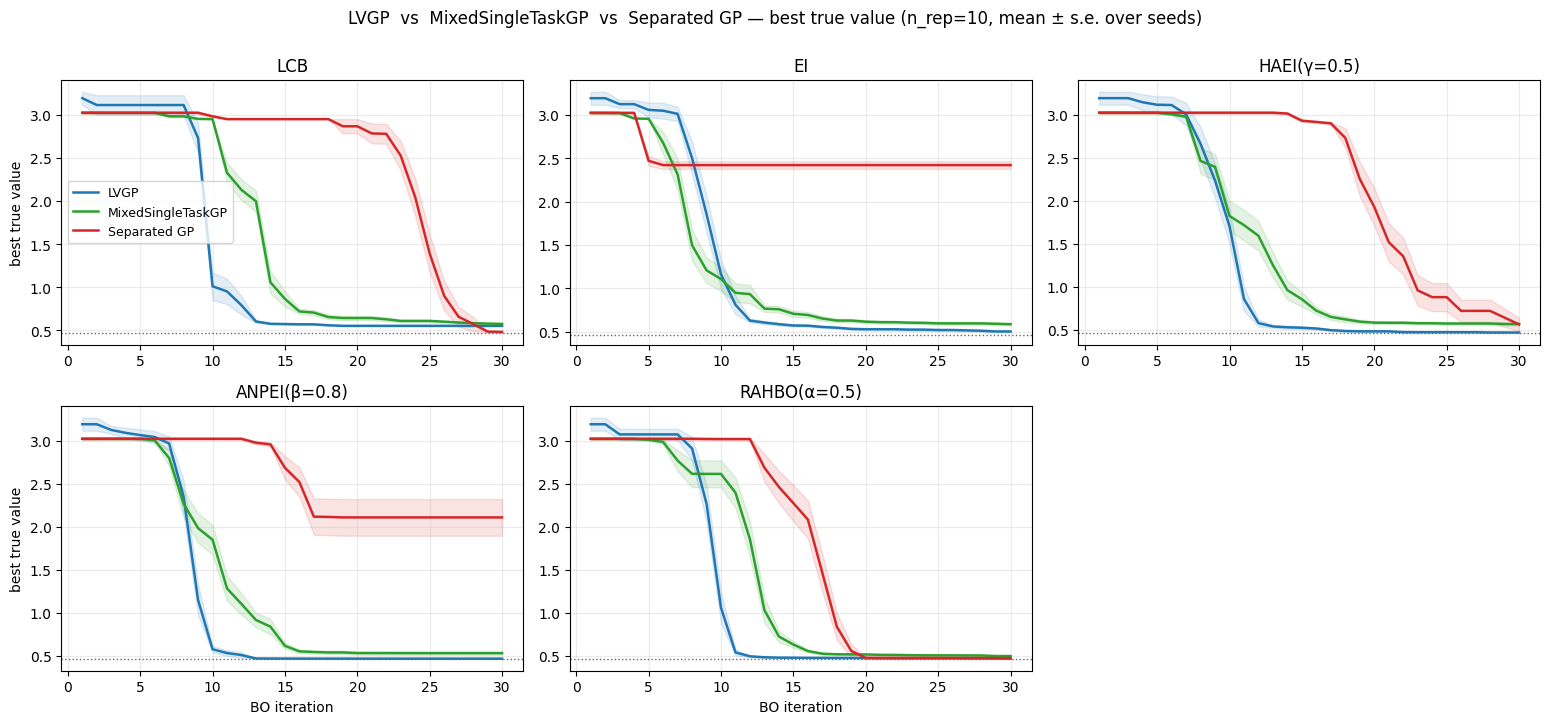

In [ ]:
fig1 = compare_studies_multi(studies, is_ground_truth=True, as_regret=False,
                              n_rep=N_REP_MAIN, configs=HEADLINE_TAGS, ncols=3)
fig1.savefig(os.path.join(EXCEL_DIR, "1_model_comparison_value.png"), dpi=150, bbox_inches="tight")

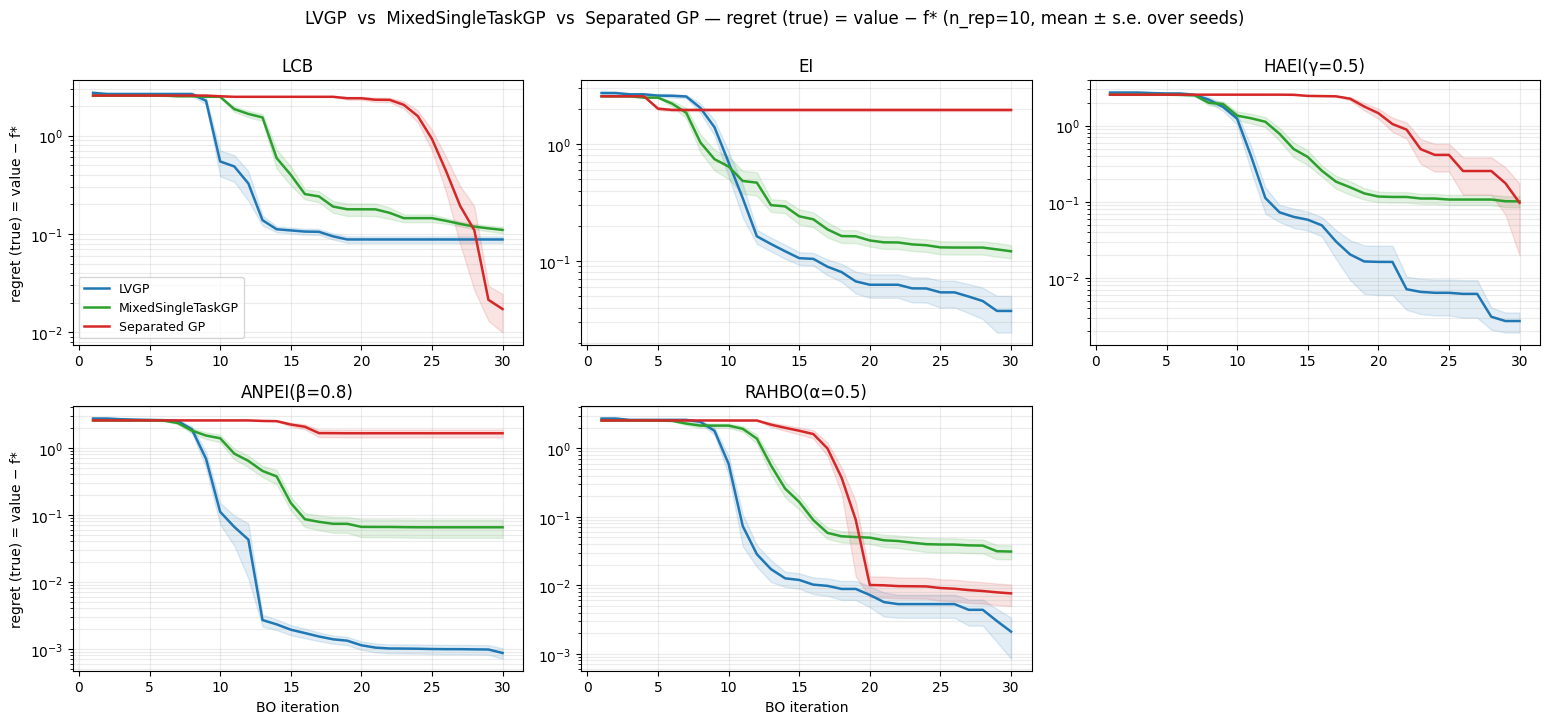

In [ ]:
# same comparison as regret (value - f*) on a log axis -- convergence RATE, not just final value
fig1b = compare_studies_multi(studies, is_ground_truth=True, as_regret=True,
                               n_rep=N_REP_MAIN, configs=HEADLINE_TAGS, ncols=3)
fig1b.savefig(os.path.join(EXCEL_DIR, "1_model_comparison_regret.png"), dpi=150, bbox_inches="tight")

## 2. Acquisition comparison under LVGP only

EI, LCB, PI, best-γ HAEI, best-β ANPEI, best-α RAHBO -- isolating the acquisition-function
effect from the model effect. Three metrics vs iteration, all evaluated at the TRUE-ranked
incumbent (the same selection rule as everywhere else in this repo):
best true objective, true variance σ²(x) of that incumbent, and the robust objective
f(x) + ALPHA_EVAL·σ²(x).

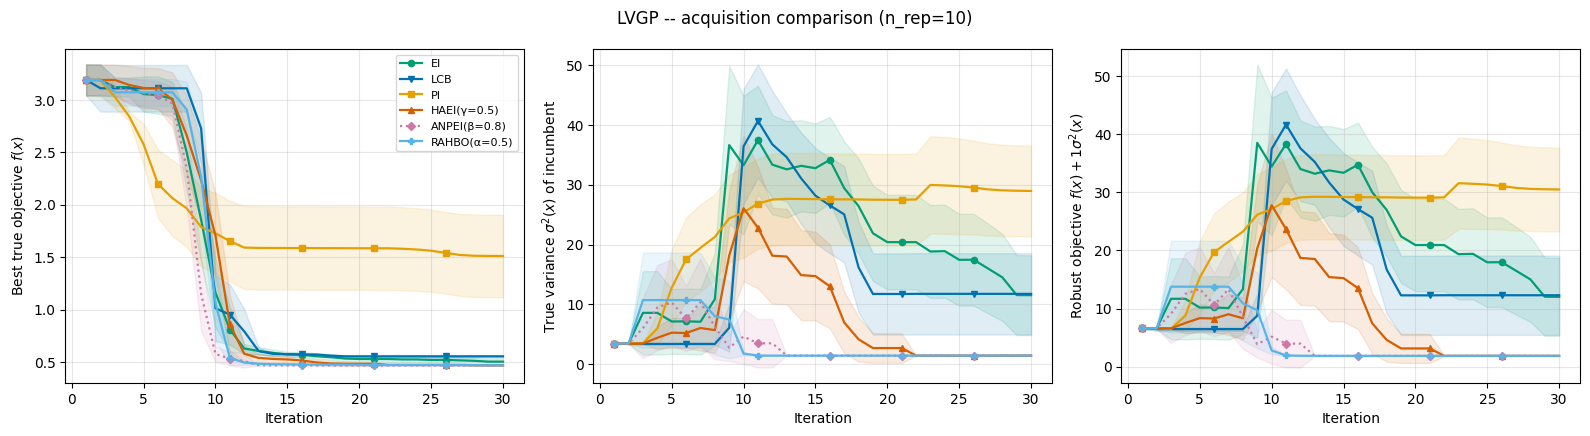

In [ ]:
def incumbent_trajectories(study, cfgs, n_rep, alpha_eval=ALPHA_EVAL):
    """{cfg: dict(it, obj=(mean,sem), var=(mean,sem), robust=(mean,sem))} -- per-iteration
    trajectory of the TRUE-ranked incumbent's objective / variance / robust objective,
    mean +/- s.e. over seeds."""
    out = {}
    for cfg in cfgs:
        objs, varz = [], []
        for r in study.runs:
            if StudyResults.cfg_key(r) != cfg or r["n_rep"] != n_rep:
                continue
            n0 = r["n_initial"]
            key = study._true_obj_of_samples(r)
            var = study._true_var_of_samples(r)
            niter = len(key) - n0
            idx_seq = [int(np.nanargmin(key[:n0 + k])) for k in range(1, niter + 1)]
            objs.append(key[idx_seq]); varz.append(var[idx_seq])
        if not objs:
            continue
        L = min(len(o) for o in objs)
        O = np.array([o[:L] for o in objs]); V = np.array([v[:L] for v in varz])
        R = O + alpha_eval * V
        n = O.shape[0]

        def ms(A):
            m = A.mean(0)
            e = A.std(0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros(L)
            return m, e

        out[cfg] = dict(it=np.arange(1, L + 1), obj=ms(O), var=ms(V), robust=ms(R))
    return out


def plot_metric_trajectories(study, cfgs, n_rep, alpha_eval=ALPHA_EVAL, title=""):
    data = incumbent_trajectories(study, cfgs, n_rep, alpha_eval)
    panels = [("obj", "Best true objective $f(x)$"),
              ("var", "True variance $\\sigma^2(x)$ of incumbent"),
              ("robust", f"Robust objective $f(x)+{alpha_eval:g}\\sigma^2(x)$")]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for ax, (key, ylab) in zip(axes, panels):
        for cfg in cfgs:
            if cfg not in data:
                continue
            d = data[cfg]; it = d["it"]; m, e = d[key]
            st = problem.style_for(cfg[0], _cfg_param(cfg))
            ax.plot(it, m, color=st["color"], ls=st["linestyle"], marker=st["marker"],
                    markevery=max(1, len(it) // 6), ms=4.5, lw=1.6,
                    label=problem.label(cfg[0], _cfg_param(cfg)))
            ax.fill_between(it, m - 1.96 * e, m + 1.96 * e, color=st["color"], alpha=0.12)
        ax.set_xlabel("Iteration"); ax.set_ylabel(ylab); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


SECTION2_CFGS = [
    problem.canon_cfg("ei", float("nan")),
    problem.canon_cfg("lcb", float("nan")),
    problem.canon_cfg("pi", float("nan")),
    problem.canon_cfg("haei", BEST["haei"]),
    problem.canon_cfg("anpei", BEST["anpei"]),
    problem.canon_cfg("rahbo", BEST["rahbo"]),
]
fig2 = plot_metric_trajectories(lvgp, SECTION2_CFGS, N_REP_MAIN,
                                 title=f"LVGP -- acquisition comparison (n_rep={N_REP_MAIN})")
fig2.savefig(os.path.join(EXCEL_DIR, "2_lvgp_acquisition_comparison.png"), dpi=150, bbox_inches="tight")

### 2b. Zoom-in: best true objective, iterations 10-20

The same "best true objective" trajectory as the left panel above, cropped to iterations
10-20 (where the acquisitions are still separating) on its own y-scale, so the differences
between methods aren't squashed by the iteration-1 spike or the iteration-30 plateau.

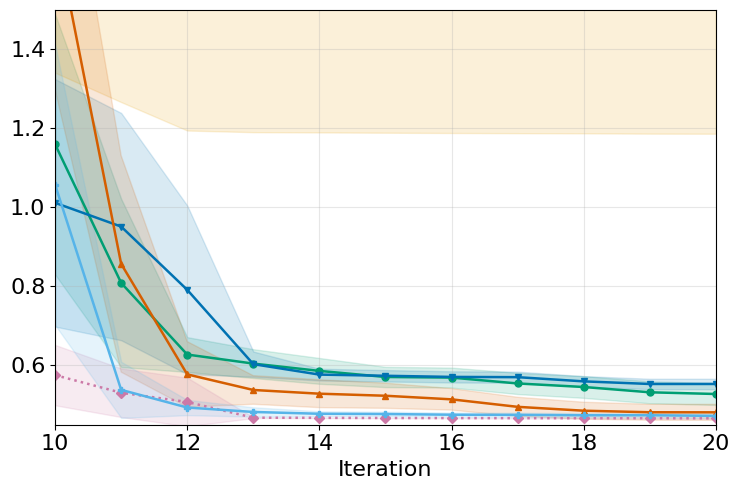

In [42]:
def plot_obj_zoom(study, cfgs, n_rep, it_range=(10, 20), alpha_eval=ALPHA_EVAL, title=""):
    data = incumbent_trajectories(study, cfgs, n_rep, alpha_eval)
    lo, hi = it_range
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for cfg in cfgs:
        if cfg not in data:
            continue
        d = data[cfg]; it = d["it"]; m, e = d["obj"]
        mask = (it >= lo) & (it <= hi)
        if not mask.any():
            continue
        st = problem.style_for(cfg[0], _cfg_param(cfg))
        ax.plot(it[mask], m[mask], color=st["color"], ls=st["linestyle"], marker=st["marker"],
                ms=5, lw=1.8, label=problem.label(cfg[0], _cfg_param(cfg)))
        ax.fill_between(it[mask], (m - 1.96 * e)[mask], (m + 1.96 * e)[mask],
                         color=st["color"], alpha=0.15)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0.45, 1.5)
    fs = 16
    ax.set_xlabel("Iteration", fontsize=fs)
    # ax.set_ylabel("Best true objective $f(x)$", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    ax.grid(alpha=0.3)
    # ax.legend(fontsize=fs)
    # ax.set_title(title, fontsize=fs)
    fig.tight_layout()
    return fig


fig2b = plot_obj_zoom(lvgp, SECTION2_CFGS, N_REP_MAIN, it_range=(10, 20),
                       title=f"LVGP -- best true objective, iterations 10-20 (n_rep={N_REP_MAIN})")
fig2b.savefig(os.path.join(EXCEL_DIR, "2b_lvgp_acquisition_obj_zoom_10_20.png"), dpi=150, bbox_inches="tight")

## 3. Final performance summary table

Mean ± s.e. over the 30 seeds, at `n_rep=10`, for every (model, acquisition,
hyperparameter) cell: final best true f(x), final true variance σ²(x), final robust objective
f(x)+ALPHA_EVAL·σ²(x), and the success rate
(`final_true_f <= f_min + 0.05*(f_max-f_min)`).

In [ ]:
def summary_table(df, n_rep=N_REP_MAIN):
    sub = df[df.n_rep == n_rep].copy()

    def agg(g):
        n = len(g)

        def me(col):
            m = g[col].mean()
            se = g[col].std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
            return f"{m:.4f} ± {se:.4f}"

        return pd.Series({
            "Final best true f(x)": me("final_true_f"),
            "Final true variance σ²(x)": me("final_true_var"),
            f"Robust objective f+{ALPHA_EVAL:g}σ²": me("robust_obj"),
            "Success rate": f"{100 * g['success'].mean():.0f}%",
            "n_seeds": n,
        })

    out = sub.groupby(["model", "acq_label", "param"], dropna=False).apply(agg).reset_index()
    out = out.rename(columns={"model": "Model", "acq_label": "Acquisition", "param": "Hyperparameter"})
    out["Hyperparameter"] = out["Hyperparameter"].apply(lambda p: "" if pd.isna(p) else f"{p:g}")
    model_rank = {m: i for i, m in enumerate(MODEL_LABELS)}
    acq_rank = {problem.label(a, p): i for i, (a, p) in enumerate(problem.CONFIG_ORDER)}
    out["_mr"] = out["Model"].map(model_rank)
    out["_ar"] = out["Acquisition"].map(acq_rank)
    out = out.sort_values(["_mr", "_ar"]).drop(columns=["_mr", "_ar"]).reset_index(drop=True)
    return out


FINAL_TABLE = summary_table(LONG_DF, N_REP_MAIN)
FINAL_TABLE.to_excel(os.path.join(EXCEL_DIR, "3_final_summary_table.xlsx"), index=False)
FINAL_TABLE

,Model,Acquisition,Hyperparameter,Final best true f(x),Final true variance σ²(x),Robust objective f+1σ²,Success rate,n_seeds
0,LVGP,LCB,,0.5532 ± 0.0067,11.7389 ± 3.4744,12.2921 ± 3.4788,100%,30
1,LVGP,PI,,1.5105 ± 0.2011,28.9670 ± 3.8759,30.4775 ± 3.6751,100%,30
2,LVGP,EI,,0.5025 ± 0.0130,11.5194 ± 3.4092,12.0219 ± 3.4208,100%,30
3,LVGP,HAEI(γ=0.5),0.5,0.4678 ± 0.0008,1.4017 ± 0.0012,1.8695 ± 0.0005,100%,30
4,LVGP,HAEI(γ=1),1,0.4698 ± 0.0012,1.4038 ± 0.0020,1.8736 ± 0.0020,100%,30
5,LVGP,HAEI(γ=5),5,0.4739 ± 0.0026,1.4020 ± 0.0028,1.8759 ± 0.0033,100%,30
6,LVGP,ANPEI(β=0.2),0.2,1.2978 ± 0.2077,1.8708 ± 0.1597,3.1687 ± 0.3626,100%,30
7,LVGP,ANPEI(β=0.5),0.5,0.5193 ± 0.0143,1.3801 ± 0.0048,1.8994 ± 0.0101,100%,30
8,LVGP,ANPEI(β=0.8),0.8,0.4660 ± 0.0002,1.4051 ± 0.0008,1.8710 ± 0.0007,100%,30
9,LVGP,RAHBO(α=0.5),0.5,0.4672 ± 0.0013,1.4068 ± 0.0014,1.8740 ± 0.0010,100%,30


**Caveat on success rate:** with `f_max` taken as the global domain maximum (~308, an
extreme corner of the input space BO never actually visits), the 5% tolerance band is
~15.4 -- far wider than any final objective BO actually reports here (mostly < 3). So
every configuration's success rate prints as 100% above; it isn't discriminating for this
problem. To make it discriminating, re-run with a tighter, more local `SUCCESS_THRESHOLD`,
e.g. `F_MIN + 0.05 * (LONG_DF.final_true_f.median() - F_MIN)`, or a fixed absolute tolerance.

## 4. Final objective–variance scatter

One point per seed: x = final true objective, y = final true variance, faceted by model,
colored by acquisition (the 5 headline cases). Heteroscedastic-aware acquisitions
(HAEI/ANPEI/RAHBO) should cluster toward the lower-left (low f **and** low σ²), not just
low f.

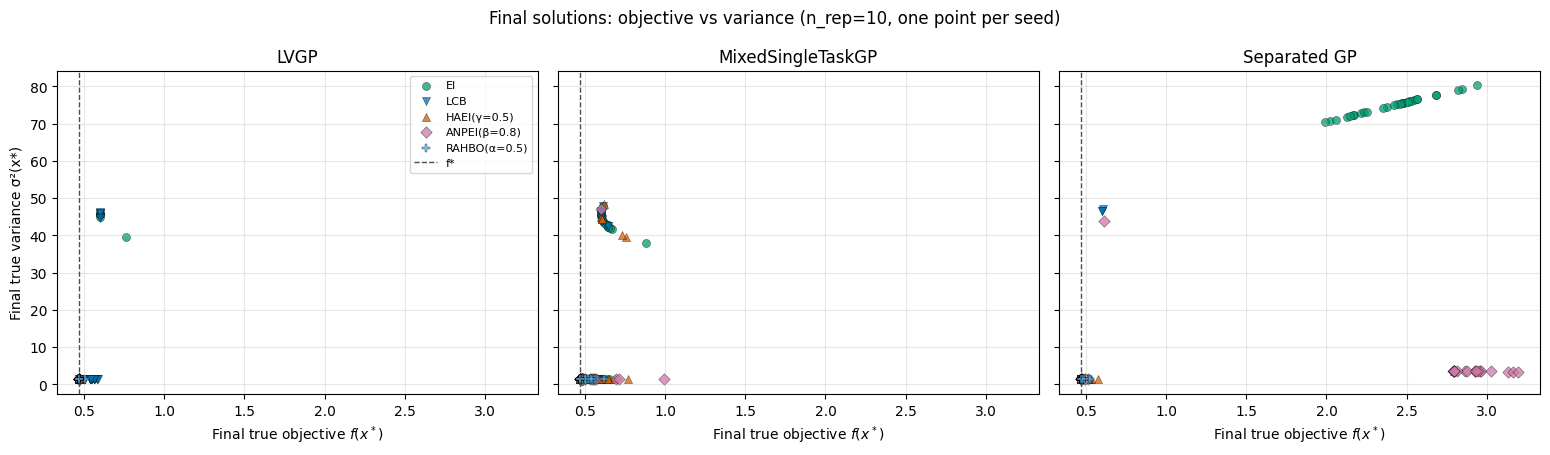

In [36]:
def plot_obj_var_scatter(df, cfgs, labels, n_rep=N_REP_MAIN):
    colors = [problem.style_for(c[0], _cfg_param(c))["color"] for c in cfgs]
    markers = [problem.style_for(c[0], _cfg_param(c))["marker"] for c in cfgs]
    fig, axes = plt.subplots(1, len(MODEL_LABELS), figsize=(5.2 * len(MODEL_LABELS), 4.6),
                              sharex=True, sharey=True)
    for ax, model in zip(axes, MODEL_LABELS):
        for cfg, lab, col, mk in zip(cfgs, labels, colors, markers):
            d = df[(df.model == model) & select_cfg(df, cfg) & (df.n_rep == n_rep)]
            if d.empty:
                continue
            ax.scatter(d.final_true_f, d.final_true_var, color=col, marker=mk, s=34, alpha=0.75,
                       edgecolor="k", linewidth=0.3, label=lab)
        ax.axvline(F_MIN, color="0.3", ls="--", lw=1, label="f*" if model == MODEL_LABELS[0] else None)
        ax.set_title(model); ax.set_xlabel("Final true objective $f(x^*)$"); ax.grid(alpha=0.3)
    axes[0].set_ylabel("Final true variance σ²(x*)")
    axes[0].legend(fontsize=8, loc="upper right")
    fig.suptitle(f"Final solutions: objective vs variance (n_rep={n_rep}, one point per seed)")
    fig.tight_layout()
    return fig


fig4 = plot_obj_var_scatter(LONG_DF, HEADLINE_CFGS, HEADLINE_LABELS, N_REP_MAIN)
fig4.savefig(os.path.join(EXCEL_DIR, "4_objective_variance_scatter.png"), dpi=150, bbox_inches="tight")

## 5. Hyperparameter sensitivity (LVGP only)

Boxplots over the 30 seeds (`n_rep=10`) of the 3 metrics for each hyperparameter
value, one figure per family: HAEI (γ=0.5,1,5), ANPEI (β=0.2,0.5,0.8), RAHBO (α=0.5,1,5).

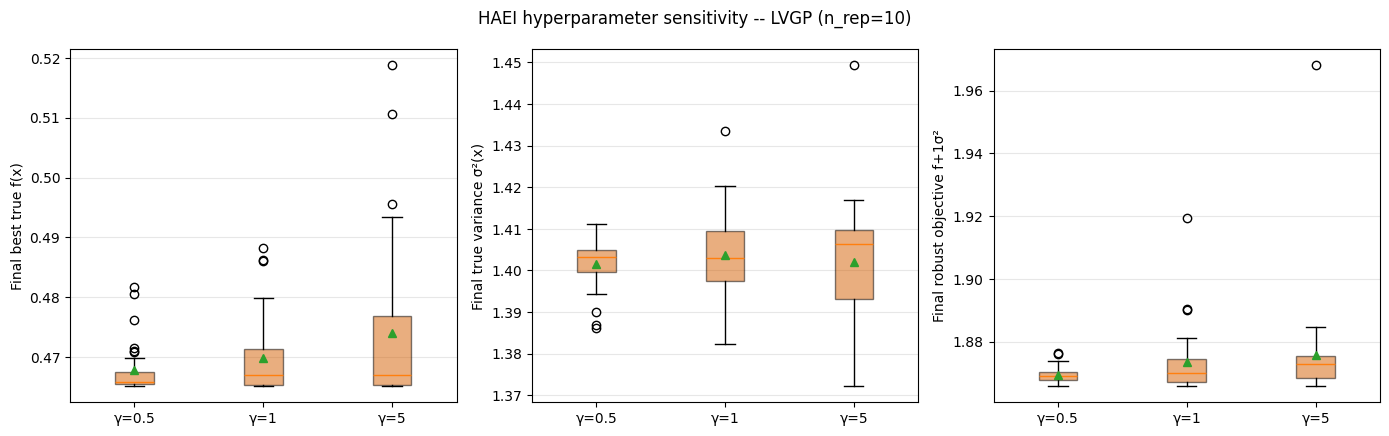

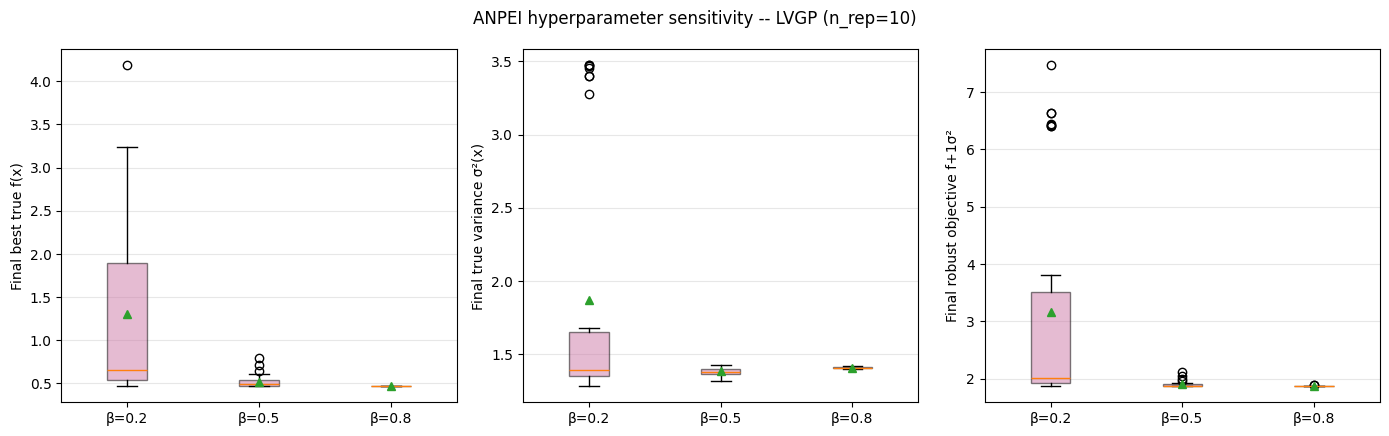

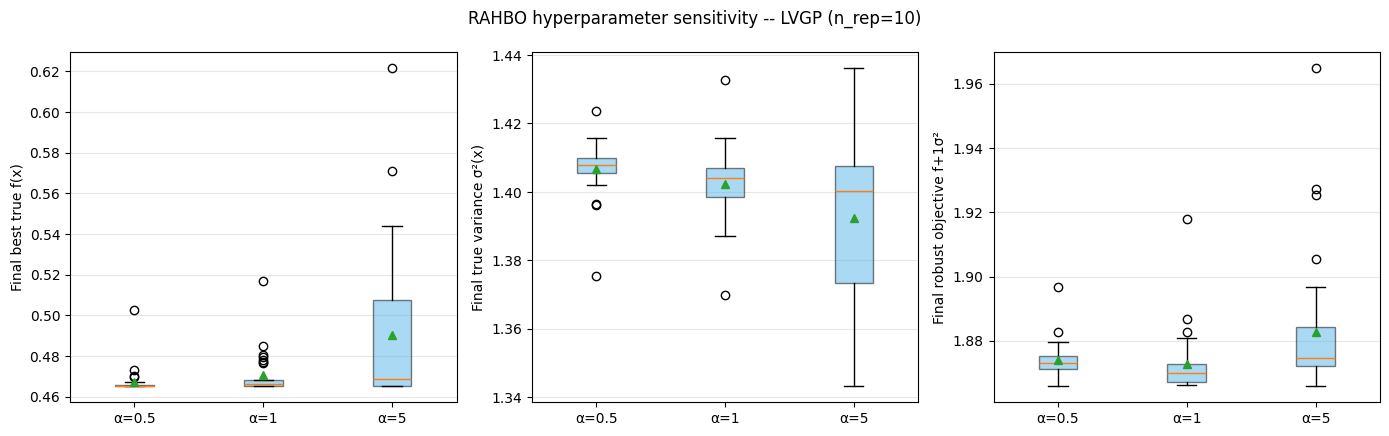

In [37]:
def hyperparam_boxplots(df, model, family, n_rep=N_REP_MAIN):
    sub = df[(df.model == model) & (df.acf == family) & (df.n_rep == n_rep)]
    params = sorted(sub.param.unique())
    knob = {"haei": "γ", "anpei": "β", "rahbo": "α"}[family]
    metrics = [("final_true_f", "Final best true f(x)"),
               ("final_true_var", "Final true variance σ²(x)"),
               ("robust_obj", f"Final robust objective f+{ALPHA_EVAL:g}σ²")]
    color = problem.FAMILY_COLOR[family]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    for ax, (col, ylab) in zip(axes, metrics):
        data = [sub[sub.param == p][col].values for p in params]
        bp = ax.boxplot(data, labels=[f"{knob}={p:g}" for p in params],
                         patch_artist=True, showmeans=True)
        for patch in bp["boxes"]:
            patch.set_facecolor(color); patch.set_alpha(0.5)
        ax.set_ylabel(ylab); ax.grid(alpha=0.3, axis="y")
    fig.suptitle(f"{family.upper()} hyperparameter sensitivity -- {model} (n_rep={n_rep})")
    fig.tight_layout()
    return fig


figs5 = {}
for fam in ("haei", "anpei", "rahbo"):
    f = hyperparam_boxplots(LONG_DF, "LVGP", fam, N_REP_MAIN)
    f.savefig(os.path.join(EXCEL_DIR, f"5_hyperparam_sensitivity_{fam}.png"), dpi=150, bbox_inches="tight")
    figs5[fam] = f

## 6. Replicate sensitivity

Final true f(x), final true variance σ²(x), and robust objective vs `n_rep` for EI and the
best HAEI/ANPEI/RAHBO settings, faceted by model -- does more replicates per location actually
improve heteroscedastic learning? (Only `n_rep in {3, 5, 10}` exists in the sweep.)

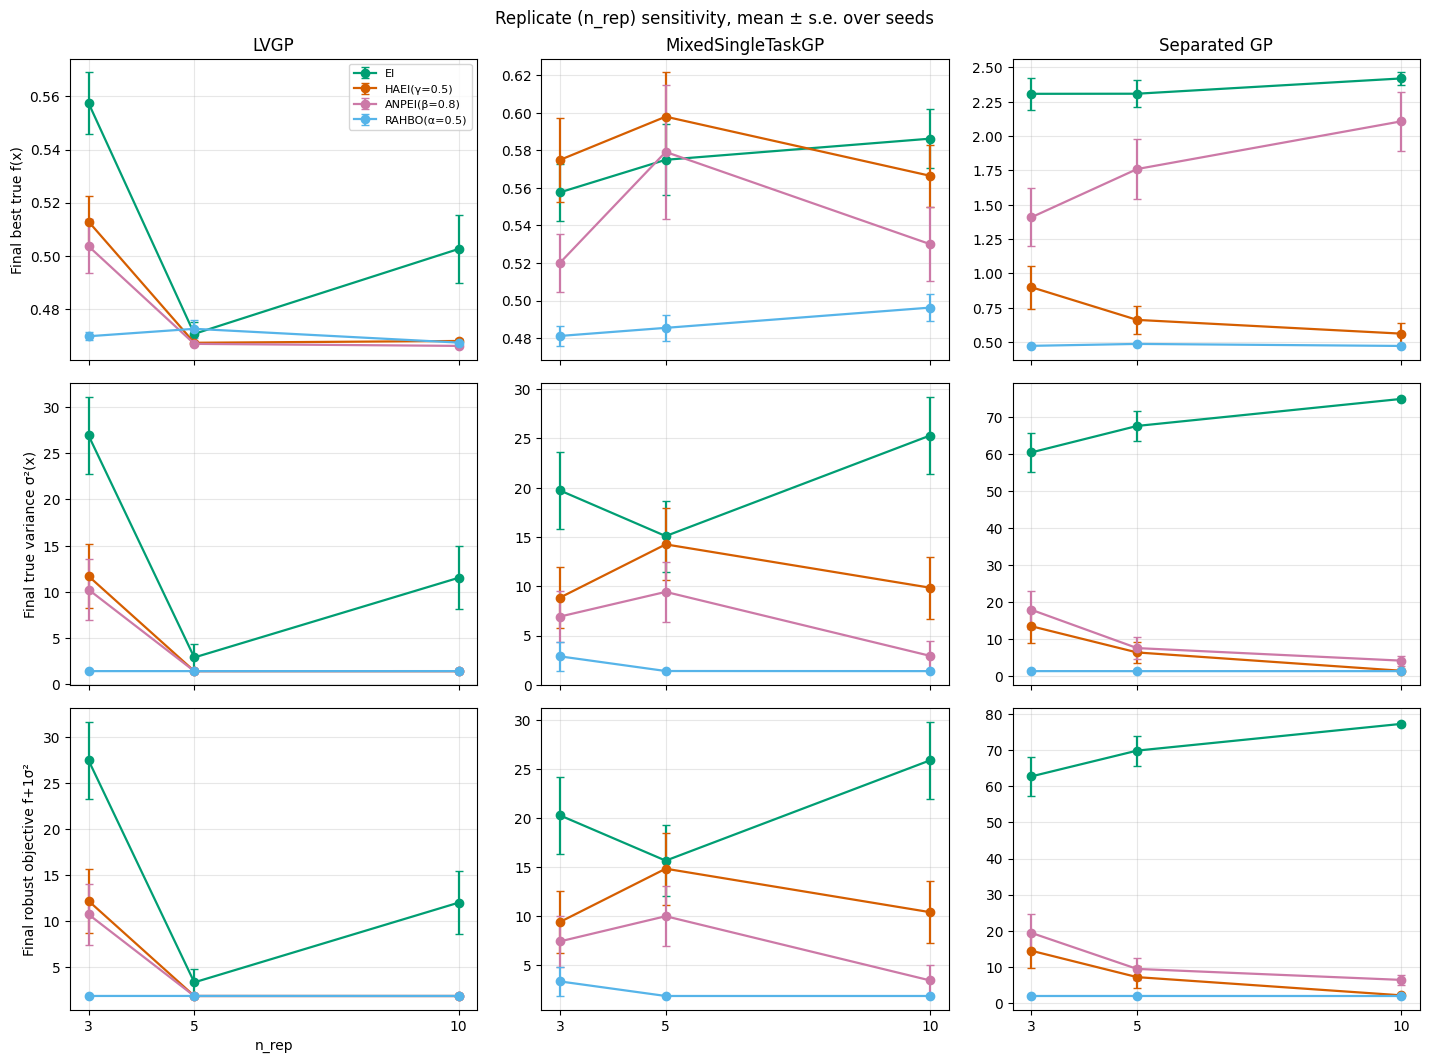

In [ ]:
def replicate_sensitivity(df, cfgs, labels):
    n_reps = sorted(df.n_rep.unique())
    metrics = [("final_true_f", "Final best true f(x)"),
               ("final_true_var", "Final true variance σ²(x)"),
               ("robust_obj", f"Final robust objective f+{ALPHA_EVAL:g}σ²")]
    colors = [problem.style_for(c[0], _cfg_param(c))["color"] for c in cfgs]
    fig, axes = plt.subplots(len(metrics), len(MODEL_LABELS),
                              figsize=(4.8 * len(MODEL_LABELS), 3.6 * len(metrics)), sharex=True)
    for i, (col, ylab) in enumerate(metrics):
        for j, model in enumerate(MODEL_LABELS):
            ax = axes[i][j]
            for cfg, lab, color in zip(cfgs, labels, colors):
                xs, ys, es = [], [], []
                for nr in n_reps:
                    d = df[(df.model == model) & select_cfg(df, cfg) & (df.n_rep == nr)][col]
                    if len(d):
                        xs.append(nr); ys.append(d.mean())
                        es.append(d.std(ddof=1) / np.sqrt(len(d)) if len(d) > 1 else 0.0)
                ax.errorbar(xs, ys, yerr=es, marker="o", lw=1.6, capsize=3, color=color, label=lab)
            if i == 0:
                ax.set_title(model)
            if j == 0:
                ax.set_ylabel(ylab)
            ax.set_xticks(n_reps); ax.grid(alpha=0.3)
    axes[-1][0].set_xlabel("n_rep")
    axes[0][0].legend(fontsize=8)
    fig.suptitle("Replicate (n_rep) sensitivity, mean ± s.e. over seeds")
    fig.tight_layout()
    return fig


SECTION6_CFGS = [
    problem.canon_cfg("ei", float("nan")),
    problem.canon_cfg("haei", BEST["haei"]),
    problem.canon_cfg("anpei", BEST["anpei"]),
    problem.canon_cfg("rahbo", BEST["rahbo"]),
]
SECTION6_LABELS = [problem.label(c[0], _cfg_param(c)) for c in SECTION6_CFGS]
fig6 = replicate_sensitivity(LONG_DF, SECTION6_CFGS, SECTION6_LABELS)
fig6.savefig(os.path.join(EXCEL_DIR, "6_replicate_sensitivity.png"), dpi=150, bbox_inches="tight")